# 03. Эксперименты с моделями

В этом ноутбуке проводятся первые эксперименты с моделями классификации для задачи предсказания отказа промышленного оборудования.

В отличие от baseline-ноутбука, здесь используются новые признаки, созданные на этапе feature engineering.

Цели ноутбука:

- применить feature engineering;
- обучить несколько моделей классификации;
- сравнить модели на validation-выборке;
- выбрать лучшую модель по основной метрике PR-AUC;
- проверить лучшую модель на test-выборке.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "ai4i2020.csv"

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_PATH

WindowsPath('C:/Users/vladp/Documents/MLProjects/hseml-group-project-vlad010305/data/raw/ai4i2020.csv')

In [3]:
from src.features import add_features
from src.modeling import evaluate_classifier, make_results_table
from src.preprocessing import split_features_target, make_train_val_test_split

## 1. Загрузка данных

In [4]:
df = pd.read_csv(DATA_PATH)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1000,308.6000,1551,42.8000,0,0,0,0,0,0,0
1,2,L47181,L,298.2000,308.7000,1408,46.3000,3,0,0,0,0,0,0
2,3,L47182,L,298.1000,308.5000,1498,49.4000,5,0,0,0,0,0,0
3,4,L47183,L,298.2000,308.6000,1433,39.5000,7,0,0,0,0,0,0
4,5,L47184,L,298.2000,308.7000,1408,40.0000,9,0,0,0,0,0,0


## 2. Feature engineering

Добавим новые признаки, основанные на физических параметрах оборудования:

- `temperature_diff` — разница между температурой процесса и температурой воздуха;
- `power_proxy` — приближённая нагрузка как произведение скорости вращения и крутящего момента;
- `torque_per_rpm` — отношение крутящего момента к скорости вращения;
- `wear_torque_interaction` — взаимодействие износа инструмента и крутящего момента.

In [5]:
df_fe = add_features(df)

df_fe.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,temperature_diff,power_proxy,torque_per_rpm,wear_torque_interaction
0,1,M14860,M,298.1000,308.6000,1551,42.8000,0,0,0,0,0,0,0,10.5000,66382.8000,0.0276,0.0000
1,2,L47181,L,298.2000,308.7000,1408,46.3000,3,0,0,0,0,0,0,10.5000,65190.4000,0.0329,138.9000
2,3,L47182,L,298.1000,308.5000,1498,49.4000,5,0,0,0,0,0,0,10.4000,74001.2000,0.0330,247.0000
3,4,L47183,L,298.2000,308.6000,1433,39.5000,7,0,0,0,0,0,0,10.4000,56603.5000,0.0276,276.5000
4,5,L47184,L,298.2000,308.7000,1408,40.0000,9,0,0,0,0,0,0,10.5000,56320.0000,0.0284,360.0000


In [6]:
new_features = [
    "temperature_diff",
    "power_proxy",
    "torque_per_rpm",
    "wear_torque_interaction",
]

df_fe[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_diff,10000.0000,10.0006,1.0011,7.6000,9.3000,9.8000,11.0000,12.1000
power_proxy,10000.0000,59967.1470,10193.0939,10966.8000,53105.4000,59883.9000,66873.7500,99980.4000
torque_per_rpm,10000.0000,0.0269,0.0088,0.0013,0.0206,0.0267,0.0328,0.0638
wear_torque_interaction,10000.0000,4314.6646,2826.5677,0.0000,1963.6500,4012.9500,6279.0000,16497.0000


## 3. Разделение на признаки и целевую переменную

Как и в baseline-эксперименте, из признаков исключаются:

- `UDI`, `Product ID` — идентификаторы;
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF` — признаки типов отказов, которые могут привести к data leakage.

In [7]:
X, y = split_features_target(df_fe)

X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temperature_diff,power_proxy,torque_per_rpm,wear_torque_interaction
0,M,298.1000,308.6000,1551,42.8000,0,10.5000,66382.8000,0.0276,0.0000
1,L,298.2000,308.7000,1408,46.3000,3,10.5000,65190.4000,0.0329,138.9000
2,L,298.1000,308.5000,1498,49.4000,5,10.4000,74001.2000,0.0330,247.0000
3,L,298.2000,308.6000,1433,39.5000,7,10.4000,56603.5000,0.0276,276.5000
4,L,298.2000,308.7000,1408,40.0000,9,10.5000,56320.0000,0.0284,360.0000


In [8]:
X.shape, y.shape

((10000, 10), (10000,))

## 4. Train / validation / test split

Данные разделяются на train/validation/test в пропорции 70/15/15 со стратификацией по целевой переменной.

In [9]:
X_train, X_val, X_test, y_train, y_val, y_test = make_train_val_test_split(X, y)

X_train.shape, X_val.shape, X_test.shape

((7000, 10), (1500, 10), (1500, 10))

In [10]:
split_distribution = pd.DataFrame(
    {
        "train": y_train.value_counts(normalize=True).sort_index(),
        "validation": y_val.value_counts(normalize=True).sort_index(),
        "test": y_test.value_counts(normalize=True).sort_index(),
    }
)

split_distribution

,train,validation,test
Machine failure,,,
0,0.9661,0.9660,0.9660
1,0.0339,0.0340,0.0340


## 5. Подготовка признаков

Для разных типов моделей используются разные схемы предобработки:

- для линейных моделей числовые признаки масштабируются с помощью `StandardScaler`;
- для моделей на основе деревьев масштабирование не требуется;
- категориальный признак `Type` кодируется с помощью `OneHotEncoder`.

Все преобразования выполняются внутри `sklearn Pipeline`, чтобы избежать data leakage.

In [11]:
categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features, numeric_features

(['Type'],
 ['Air temperature [K]',
  'Process temperature [K]',
  'Rotational speed [rpm]',
  'Torque [Nm]',
  'Tool wear [min]',
  'temperature_diff',
  'power_proxy',
  'torque_per_rpm',
  'wear_torque_interaction'])

In [12]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

## 6. Список моделей для экспериментов

В рамках первых экспериментов проверим несколько моделей:

- `LogisticRegression`;
- `LogisticRegression` с `class_weight='balanced'`;
- `RandomForestClassifier`;
- `ExtraTreesClassifier`;
- `GradientBoostingClassifier`;
- `HistGradientBoostingClassifier`.

Это позволит сравнить простую линейную модель с несколькими нелинейными моделями на основе деревьев.

In [13]:
models = {
    "Logistic Regression FE": Pipeline(
        steps=[
            ("preprocessor", preprocessor_scaled),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Logistic Regression Balanced FE": Pipeline(
        steps=[
            ("preprocessor", preprocessor_scaled),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "Random Forest FE": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "Extra Trees FE": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            (
                "model",
                ExtraTreesClassifier(
                    n_estimators=300,
                    max_depth=None,
                    min_samples_leaf=2,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "Gradient Boosting FE": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            (
                "model",
                GradientBoostingClassifier(
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "HistGradientBoosting FE": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            (
                "model",
                HistGradientBoostingClassifier(
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
}

## 7. Обучение и оценка моделей

Обучим каждую модель на train-выборке и оценим качество на validation-выборке.

Основная метрика — PR-AUC. Дополнительно смотрим ROC-AUC, F1-score, Precision и Recall.

In [14]:
results = []

for model_name, model in models.items():
    print(f"Training: {model_name}")

    model.fit(X_train, y_train)
    metrics = evaluate_classifier(model, X_val, y_val)

    results.append(
        {
            "experiment": model_name,
            "features": "feature engineering",
            **metrics,
        }
    )

results_df = make_results_table(results)
results_df

Training: Logistic Regression FE
Training: Logistic Regression Balanced FE
Training: Random Forest FE
Training: Extra Trees FE
Training: Gradient Boosting FE
Training: HistGradientBoosting FE


,experiment,features,PR-AUC,ROC-AUC,F1,Precision,Recall,TN,FP,FN,TP
4,Gradient Boosting FE,feature engineering,0.8661,0.9532,0.8132,0.9250,0.7255,1446,3,14,37
2,Random Forest FE,feature engineering,0.8422,0.9569,0.8298,0.9070,0.7647,1445,4,12,39
5,HistGradientBoosting FE,feature engineering,0.8351,0.9451,0.8298,0.9070,0.7647,1445,4,12,39
3,Extra Trees FE,feature engineering,0.7625,0.9371,0.6863,0.6863,0.6863,1433,16,16,35
0,Logistic Regression FE,feature engineering,0.3900,0.8726,0.3143,0.5789,0.2157,1441,8,40,11
1,Logistic Regression Balanced FE,feature engineering,0.3454,0.8860,0.2360,0.1402,0.7451,1216,233,13,38


## 8. Таблица экспериментов

Отсортируем модели по основной метрике PR-AUC.

In [15]:
results_df.sort_values("PR-AUC", ascending=False)

,experiment,features,PR-AUC,ROC-AUC,F1,Precision,Recall,TN,FP,FN,TP
4,Gradient Boosting FE,feature engineering,0.8661,0.9532,0.8132,0.9250,0.7255,1446,3,14,37
2,Random Forest FE,feature engineering,0.8422,0.9569,0.8298,0.9070,0.7647,1445,4,12,39
5,HistGradientBoosting FE,feature engineering,0.8351,0.9451,0.8298,0.9070,0.7647,1445,4,12,39
3,Extra Trees FE,feature engineering,0.7625,0.9371,0.6863,0.6863,0.6863,1433,16,16,35
0,Logistic Regression FE,feature engineering,0.3900,0.8726,0.3143,0.5789,0.2157,1441,8,40,11
1,Logistic Regression Balanced FE,feature engineering,0.3454,0.8860,0.2360,0.1402,0.7451,1216,233,13,38


In [16]:
results_df[
    [
        "experiment",
        "PR-AUC",
        "ROC-AUC",
        "F1",
        "Precision",
        "Recall",
        "TN",
        "FP",
        "FN",
        "TP",
    ]
]

,experiment,PR-AUC,ROC-AUC,F1,Precision,Recall,TN,FP,FN,TP
4,Gradient Boosting FE,0.8661,0.9532,0.8132,0.9250,0.7255,1446,3,14,37
2,Random Forest FE,0.8422,0.9569,0.8298,0.9070,0.7647,1445,4,12,39
5,HistGradientBoosting FE,0.8351,0.9451,0.8298,0.9070,0.7647,1445,4,12,39
3,Extra Trees FE,0.7625,0.9371,0.6863,0.6863,0.6863,1433,16,16,35
0,Logistic Regression FE,0.3900,0.8726,0.3143,0.5789,0.2157,1441,8,40,11
1,Logistic Regression Balanced FE,0.3454,0.8860,0.2360,0.1402,0.7451,1216,233,13,38


## 9. Выводы по validation-экспериментам

По результатам экспериментов на validation-выборке видно, что модели на основе деревьев значительно превзошли логистическую регрессию.

Лучший результат по основной метрике PR-AUC показала модель `Gradient Boosting FE`:

- PR-AUC = 0.8661;
- ROC-AUC = 0.9532;
- F1 = 0.8132;
- Precision = 0.9250;
- Recall = 0.7255.

`Random Forest FE` и `HistGradientBoosting FE` показали немного более высокий F1-score, но уступили по основной метрике PR-AUC.

Так как основной метрикой проекта выбрана PR-AUC, в качестве финальной модели на данном этапе выбирается `Gradient Boosting FE`.

По сравнению с baseline-моделью качество существенно выросло. Это показывает, что feature engineering и нелинейные модели лучше подходят для данной задачи.

## 10. Выбор лучшей модели

Выберем лучшую модель по основной метрике PR-AUC на validation-выборке.

In [17]:
best_model_name = results_df.sort_values("PR-AUC", ascending=False).iloc[0]["experiment"]
best_model_name

'Gradient Boosting FE'

In [18]:
best_model = models[best_model_name]
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 11. Финальная оценка на test-выборке

После выбора лучшей модели по validation-выборке оценим её качество на отложенной test-выборке.

Test-выборка не использовалась при выборе модели, поэтому она позволяет получить более честную оценку качества.

In [19]:
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

X_train_full.shape, y_train_full.shape

((8500, 10), (8500,))

In [20]:
final_model = models[best_model_name]

final_model.fit(X_train_full, y_train_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [21]:
test_metrics = evaluate_classifier(
    final_model,
    X_test,
    y_test,
)

test_metrics

{'PR-AUC': 0.9300594708196257,
 'ROC-AUC': 0.9774489505947307,
 'F1': 0.9375,
 'Precision': 1.0,
 'Recall': 0.8823529411764706,
 'TN': np.int64(1449),
 'FP': np.int64(0),
 'FN': np.int64(6),
 'TP': np.int64(45)}

In [22]:
test_results = pd.DataFrame(
    [
        {
            "experiment": best_model_name,
            "dataset": "test",
            "features": "feature engineering",
            **test_metrics,
        }
    ]
)

test_results

,experiment,dataset,features,PR-AUC,ROC-AUC,F1,Precision,Recall,TN,FP,FN,TP
0,Gradient Boosting FE,test,feature engineering,0.9301,0.9774,0.9375,1.0000,0.8824,1449,0,6,45


На отложенной test-выборке выбранная модель `Gradient Boosting FE` показала высокое качество:

- PR-AUC = 0.9301;
- ROC-AUC = 0.9774;
- F1 = 0.9375;
- Precision = 1.0000;
- Recall = 0.8824.

Модель обнаружила 45 из 51 реального отказа и не допустила ложных срабатываний на test-выборке. Это существенно лучше baseline-модели и показывает, что feature engineering вместе с нелинейной моделью хорошо подходят для данной задачи.

## 12. Confusion matrix на test-выборке

Посмотрим, какие ошибки делает выбранная модель на отложенной test-выборке.

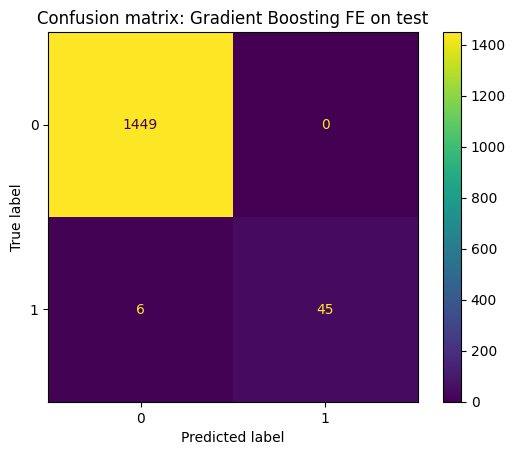

In [23]:
ConfusionMatrixDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
)

plt.title(f"Confusion matrix: {best_model_name} on test")
plt.show()

Confusion matrix показывает, что модель корректно определила все объекты без отказа и нашла большую часть реальных отказов. Основная ошибка модели — пропущенные отказы.

## 13. PR-кривая и ROC-кривая на test-выборке

Построим PR-кривую и ROC-кривую для выбранной модели на test-выборке.

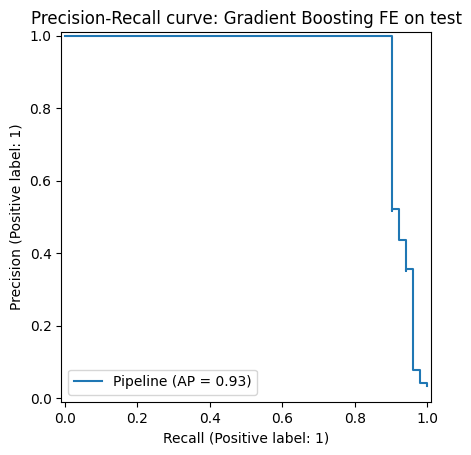

In [24]:
PrecisionRecallDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
)

plt.title(f"Precision-Recall curve: {best_model_name} on test")
plt.show()

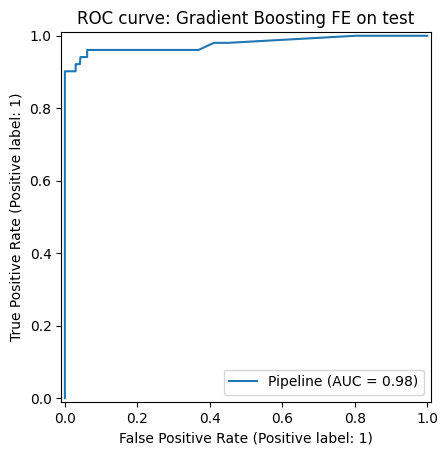

In [25]:
RocCurveDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
)

plt.title(f"ROC curve: {best_model_name} on test")
plt.show()

PR-кривая и ROC-кривая на test-выборке подтверждают высокое качество выбранной модели.

PR-AUC составляет около 0.93, что особенно важно для данной задачи, так как целевой класс сильно несбалансирован. ROC-AUC также высокий и составляет около 0.98.

Это означает, что модель хорошо ранжирует объекты по вероятности отказа и значительно превосходит baseline-модели.

## 14. Важность признаков

Для модели `GradientBoostingClassifier` можно оценить важность признаков. Это помогает понять, какие параметры оборудования сильнее всего влияют на предсказание отказа.

In [26]:
preprocessor = final_model.named_steps["preprocessor"]
model = final_model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
feature_importances = model.feature_importances_

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": feature_importances,
    }
).sort_values("importance", ascending=False)

feature_importance_df

,feature,importance
5,num__temperature_diff,0.3384
6,num__power_proxy,0.2607
8,num__wear_torque_interaction,0.2396
2,num__Rotational speed [rpm],0.0543
4,num__Tool wear [min],0.0498
10,cat__Type_L,0.0260
3,num__Torque [Nm],0.0105
7,num__torque_per_rpm,0.0102
1,num__Process temperature [K],0.0060
0,num__Air temperature [K],0.0033


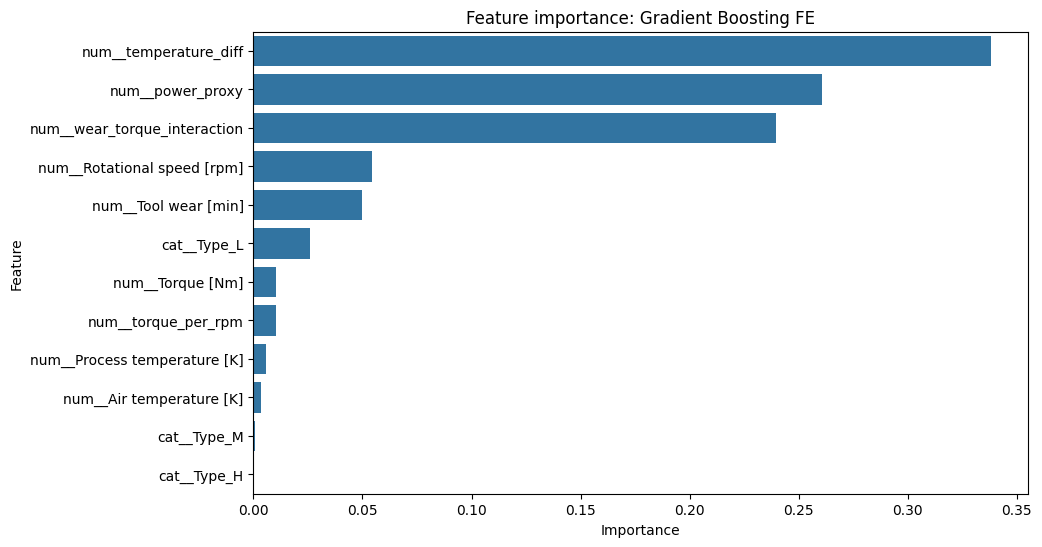

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df,
    x="importance",
    y="feature",
)

plt.title(f"Feature importance: {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Наиболее важными признаками для модели оказались:

- `temperature_diff` — разница между температурой процесса и температурой воздуха;
- `power_proxy` — приближённая нагрузка оборудования;
- `wear_torque_interaction` — взаимодействие износа инструмента и крутящего момента.

Это хороший результат для проекта, так как он показывает пользу feature engineering: новые признаки оказались важнее большинства исходных признаков.

Также модель использует исходные признаки `Rotational speed [rpm]` и `Tool wear [min]`, что соответствует результатам EDA: эти признаки заметно различались между классами отказа и нормальной работы.

Категориальные признаки типа продукта имеют меньшую важность, но `Type_L` всё же вносит небольшой вклад в предсказание.

## 15. Итоговые выводы по экспериментам

В рамках экспериментов были обучены и сравнены несколько моделей классификации:

- `LogisticRegression`;
- `LogisticRegression` с `class_weight='balanced'`;
- `RandomForestClassifier`;
- `ExtraTreesClassifier`;
- `GradientBoostingClassifier`;
- `HistGradientBoostingClassifier`.

По сравнению с baseline-моделями качество значительно выросло после добавления feature engineering и использования нелинейных моделей.

На validation-выборке лучший результат по основной метрике PR-AUC показала модель `Gradient Boosting FE`:

- PR-AUC = 0.8661;
- ROC-AUC = 0.9532;
- F1 = 0.8132;
- Precision = 0.9250;
- Recall = 0.7255.

Эта модель была выбрана как финальная модель на этапе CP1.

На отложенной test-выборке `Gradient Boosting FE` показала следующие результаты:

- PR-AUC = 0.9301;
- ROC-AUC = 0.9774;
- F1 = 0.9375;
- Precision = 1.0000;
- Recall = 0.8824.

Модель обнаружила 45 из 51 реального отказа и не допустила ложных срабатываний на test-выборке.

Анализ важности признаков показал, что наиболее полезными оказались новые признаки, созданные на этапе feature engineering: `temperature_diff`, `power_proxy` и `wear_torque_interaction`.

Таким образом, для задачи предсказания отказа промышленного оборудования на текущем этапе лучше всего себя показала модель градиентного бустинга с добавленными инженерными признаками.

## 16. Сохранение результатов

Сохраним таблицы с результатами экспериментов.

In [28]:
EXPERIMENTS_RESULTS_PATH = PROJECT_ROOT / "data" / "processed" / "experiments_results.csv"
TEST_RESULTS_PATH = PROJECT_ROOT / "data" / "processed" / "test_results.csv"
FEATURE_IMPORTANCE_PATH = PROJECT_ROOT / "data" / "processed" / "feature_importance.csv"

results_df.to_csv(EXPERIMENTS_RESULTS_PATH, index=False)
test_results.to_csv(TEST_RESULTS_PATH, index=False)
feature_importance_df.to_csv(FEATURE_IMPORTANCE_PATH, index=False)

EXPERIMENTS_RESULTS_PATH, TEST_RESULTS_PATH, FEATURE_IMPORTANCE_PATH

(WindowsPath('C:/Users/vladp/Documents/MLProjects/hseml-group-project-vlad010305/data/processed/experiments_results.csv'),
 WindowsPath('C:/Users/vladp/Documents/MLProjects/hseml-group-project-vlad010305/data/processed/test_results.csv'),
 WindowsPath('C:/Users/vladp/Documents/MLProjects/hseml-group-project-vlad010305/data/processed/feature_importance.csv'))